In [92]:
import torch
import torch.nn.functional as F
import random
import matplotlib.pyplot as plt # for making figures
%matplotlib inline


In [2]:
words = open('names.txt', 'r').read().splitlines()

In [6]:
# mappings
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi["."] = 0
itos = {i:s for s, i in stoi.items()}

In [17]:
# build the dataset
block_size = 3
def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + ".":
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)

In [26]:
# split the data
random.seed(42)
random.shuffle(words)
eighty_percent = int(0.8*len(words))
ninety_percent = int(0.9*len(words))

X_train, Y_train = build_dataset(words[:eighty_percent])
X_dev, Y_dev = build_dataset(words[eighty_percent:ninety_percent])
X_test, Y_test = build_dataset(words[:ninety_percent])

In [76]:
g = torch.Generator().manual_seed(2147483647)
# create embedding matrix, andrej uses 2d for visualization, so lets try the same
C = torch.randn((27,10), generator=g)
W1 = torch.rand((30, 200), generator=g)
B1 = torch.rand(200, generator=g)
W2 = torch.rand((200, 27), generator=g)
B2 = torch.rand(27, generator=g)
parameters = [C, W1, B1, W2, B2]

In [77]:
for p in parameters:
    p.requires_grad = True

In [85]:
for i in range(20000):
    ix = torch.randint(0, X_train.shape[0], (32,))
    
    # forward pass
    emb = C[X_train[ix]]
    h = torch.tanh(emb.view(-1, 30) @ W1 + B1)
    logits = h @ W2 + B2
    loss = F.cross_entropy(logits, Y_train[ix])
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    learning_rate = 0.1 if i < 10000 else 0.01
    for p in parameters:
        p.data += -learning_rate*p.grad
    
    

In [86]:
loss.item()

2.1258256435394287

In [90]:
# dev set
emb = C[X_dev]
h = torch.tanh(emb.view(-1, 30) @ W1 + B1)
logits = h @ W2 + B2
loss = F.cross_entropy(logits, Y_dev)
loss

tensor(2.1325, grad_fn=<NllLossBackward0>)

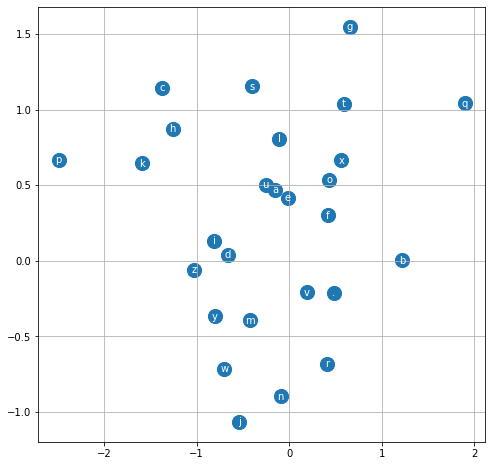

In [93]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [98]:
# build some words
for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + B1)
        logits = h @ W2 + B2
        probs = F.softmax(logits, dim=1)
        # multinomial grabs highest prob
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        # end of word
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

lovu.
dinia.
ara.
zedan.
judira.
tuw.
makinne.
kamira.
jami.
promihani.
ariyah.
jacquaiyara.
lei.
kekseir.
makenn.
han.
kynzella.
spartier.
tolc.
ney.


In [99]:
# enjoy